# 3W Dataset: Domain Distance Analysis

Quantitative measurement of the domain gap between data sources and sub-domains
using six complementary metrics (KS, Wasserstein, CORAL, MMD, CMD, Proxy A-Distance).
Includes inter-source comparisons (real, simulated, hand-drawn), intra-real splits
(well-to-well, time-period), and a unified distance summary.

## 1. Setup and data loading

We load the 3W dataset from the extracted CSVs (one directory per event class, instances split by source) and reuse the stage-1 infrastructure. All six metrics below operate on the raw observations, z-score normalized where noted.

In [1]:
import os, glob, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import seaborn as sns
from scipy import stats
from scipy.stats import ks_2samp, wasserstein_distance
from sklearn.linear_model import SGDClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import f1_score, accuracy_score
from sklearn.pipeline import Pipeline

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
np.random.seed(42)


In [2]:
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))

EXTRACTED_DATA_DIR = os.path.join(
    PROJECT_ROOT, 'data',
    'Data for A Realistic and Public Dataset with Rare Undesirable Real Events in Oil Wells',
    'data'
)

CLASS_NAMES = {
    0: 'Normal',
    1: 'Abrupt Increase of BSW',
    2: 'Spurious Closure of DHSV',
    3: 'Severe Slugging',
    4: 'Flow Instability',
    5: 'Rapid Productivity Loss',
    6: 'Quick Restriction in PCK',
    7: 'Scaling in PCK',
    8: 'Hydrate in Production Line',
}
VARIABLE_NAMES = ['P-PDG', 'P-TPT', 'T-TPT', 'P-MON-CKP',
                  'T-JUS-CKP', 'P-JUS-CKGL', 'T-JUS-CKGL', 'QGL']
SOURCES = ['real', 'simulated', 'handdrawn']


In [3]:
def detect_source(filename: str) -> str:
    name = os.path.splitext(filename)[0]
    if name.startswith('DRAWN'):   return 'handdrawn'
    if name.startswith('SIMULATED'): return 'simulated'
    if name.startswith('WELL'):    return 'real'
    return 'unknown'

def load_all_instances(data_dir: str, class_names: list) -> dict:
    all_instances = {}
    for class_code in class_names:
        class_dir = os.path.join(data_dir, str(class_code))
        if not os.path.isdir(class_dir):
            continue
        csv_files = sorted(glob.glob(os.path.join(class_dir, '*.csv')))
        if not csv_files:
            continue
        class_instances = {}
        for fpath in csv_files:
            fname = os.path.basename(fpath)
            source = detect_source(fname)
            df = pd.read_csv(fpath)
            if 'timestamp' in df.columns:
                df['timestamp'] = pd.to_datetime(df['timestamp'])
            instance_id = os.path.splitext(fname)[0]
            if source not in class_instances:
                class_instances[source] = []
            class_instances[source].append({
                'id': instance_id, 'path': fpath, 'data': df,
                'n_vars': len([c for c in df.columns if c not in ('timestamp', 'class')]),
                'n_obs': df.shape[0],
            })
        if class_instances:
            all_instances[class_code] = class_instances
    return all_instances

data = load_all_instances(EXTRACTED_DATA_DIR, CLASS_NAMES)

total = sum(sum(len(lst) for lst in src_dict.values()) for src_dict in data.values())
print(f'Loaded {total} instances across {len(data)} classes.')

Loaded 1984 instances across 9 classes.


## 2. KS test distance

The KS statistic is the largest vertical gap between the two empirical CDFs. We will compute it per variable for every source pair and visualize it as a heatmap.

- **Metric**: `D = sup_x |F1(x) - F2(x)|` (L-infinity between CDFs)
- **Range**: 0 (identical distributions) to 1 (complete separation)
- **Data**: observations pooled over the viable classes of each source pair

In [4]:
source_pairs = [('real', 'simulated'), ('real', 'handdrawn'), ('simulated', 'handdrawn')]

def get_viable_classes(data: dict, s1: str, s2: str, min_instances: int = 3) -> list:
    """
    Return classes where both sources have >= min_instances instances.
    
    Args:
        data (dict): The dataset dictionary.
        s1 (str): The first source.
        s2 (str): The second source.
        min_instances (int): Minimum number of instances required for each source.
    Returns:
        list: List of class codes that meet the criteria.
    """
    return [cls for cls in sorted(data.keys())
            if s1 in data[cls] and s2 in data[cls]
            and len(data[cls][s1]) >= min_instances
            and len(data[cls][s2]) >= min_instances]

def collect_observations(data: dict, source: str, variable: str, classes: list, max_per_instance: int = 20000) -> np.ndarray:
    """
    Collect observations for a source-variable combination across given classes.

    Args:
        data (dict): The dataset dictionary.
        source (str): The source from which to collect data.
        variable (str): The variable/column name to collect.
        classes (list): List of class codes to include in the collection.
        max_per_instance (int): Maximum number of observations to collect per instance.
    Returns:
        np.ndarray: Array of collected observations.
    """
    vals = []
    for cls in classes:
        if cls not in data or source not in data[cls]:
            continue
        for inst in data[cls][source]:
            df = inst['data']
            if variable in df.columns:
                col = df[variable].dropna().values
                if len(col) > max_per_instance:
                    idx = np.linspace(0, len(col)-1, max_per_instance, dtype=int)
                    col = col[idx]
                if len(col) > 0:
                    vals.extend(col)
    return np.array(vals)

viable_info = []
for s1, s2 in source_pairs:
    vc = get_viable_classes(data, s1, s2)
    viable_info.append({'Source pair': f'{s1} vs {s2}',
                        'Viable classes': vc,
                        'Count': len(vc)})

print('Viable classes per source pair:')
for info in viable_info:
    names = [f'{c} ({CLASS_NAMES[c][:20]})' for c in info['Viable classes']]
    print(f'\t{info["Source pair"]}: {info["Count"]} classes - {names}')

Viable classes per source pair:
	real vs simulated: 6 classes - ['1 (Abrupt Increase of B)', '2 (Spurious Closure of )', '3 (Severe Slugging)', '5 (Rapid Productivity L)', '6 (Quick Restriction in)', '8 (Hydrate in Productio)']
	real vs handdrawn: 2 classes - ['1 (Abrupt Increase of B)', '7 (Scaling in PCK)']
	simulated vs handdrawn: 1 classes - ['1 (Abrupt Increase of B)']


In [5]:
ks_results = []
for s1, s2 in source_pairs:
    viable = get_viable_classes(data, s1, s2)
    if not viable:
        continue

    for var in VARIABLE_NAMES:
        vals1 = collect_observations(data, s1, var, viable)
        vals2 = collect_observations(data, s2, var, viable)

        if len(vals1) == 0 or len(vals2) == 0:
            continue

        result = ks_2samp(vals1, vals2)
        ks_results.append({
            'source pair': f'{s1} vs {s2}',
            'Variable': var,
            'KS_statistic': result.statistic,
            'n_source': len(vals1),
            'n_target': len(vals2),
        })

ks_df = pd.DataFrame(ks_results)
display(ks_df)

,source pair,Variable,KS_statistic,n_source,n_target
0,real vs simulated,P-PDG,0.298319,1070342,18772999
1,real vs simulated,P-TPT,0.245902,1070372,18772999
2,real vs simulated,T-TPT,0.621508,1070372,14472999
3,real vs simulated,P-MON-CKP,0.222751,960918,18772999
4,real vs simulated,T-JUS-CKP,0.717689,878694,18772999
5,real vs handdrawn,P-PDG,0.758296,160221,388800
6,real vs handdrawn,P-TPT,1.000000,160221,388800
7,real vs handdrawn,T-TPT,0.541615,160221,388800
8,real vs handdrawn,P-MON-CKP,1.000000,160221,388800
9,real vs handdrawn,T-JUS-CKP,0.617341,160221,388800


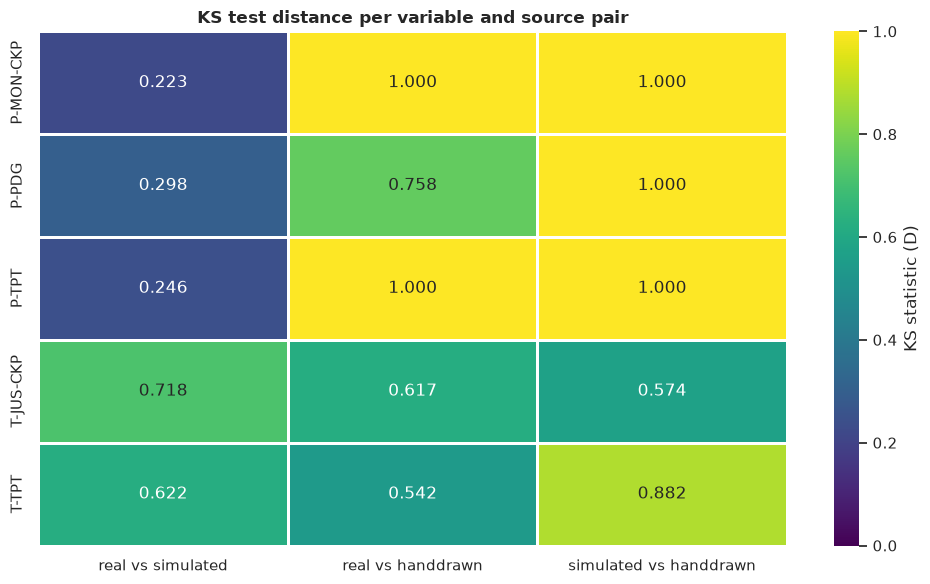

In [6]:
ks_pivot = ks_df.pivot(index='Variable', columns='source pair', values='KS_statistic')

pair_order = [f'{s1} vs {s2}' for s1, s2 in source_pairs
              if f'{s1} vs {s2}' in ks_pivot.columns]
ks_pivot = ks_pivot[pair_order]

fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(ks_pivot, annot=True, fmt='.3f', cmap='viridis',
            vmin=0, vmax=1, linewidths=1, cbar_kws={'label': 'KS statistic (D)'}, ax=ax)
ax.set_title('KS test distance per variable and source pair',
             fontweight='bold')
ax.set_ylabel('')
ax.set_xlabel('')
plt.tight_layout()
plt.show()

The KS heatmap shows the per-variable CDF separation between each source pair. Values near **1.0** mean near-complete separation: real vs hand-drawn has the most variables near KS = 1.0, while real vs simulated has more moderate values. The marginals are therefore closest between real and simulated, but later sections will show that the simulated data transfers poorly despite this.

## 3. Wasserstein distance (Earth Mover's Distance, EMD)

The Wasserstein distance is the area between the two CDFs: the minimum cost of transporting one distribution into the other. We will compute it per variable for every source pair on z-score normalized data, and inspect the most and least distant variables with a CDF overlay.

- **Metric**: `W1 = int |F1(x) - F2(x)| dx` (L1 between CDFs, pooled z-score normalization)
- **Range**: 0 (identical distributions), unbounded above
- **Interpretation**: larger values mean more mass must be moved to align the two sources

In [7]:
emd_results = []
for s1, s2 in source_pairs:
    viable = get_viable_classes(data, s1, s2)
    if not viable:
        continue

    for var in VARIABLE_NAMES:
        vals1 = collect_observations(data, s1, var, viable)
        vals2 = collect_observations(data, s2, var, viable)

        if len(vals1) < 10 or len(vals2) < 10:
            continue

        # Z-score normalization, pooled mean and std to ensure sources on the same scale
        pooled = np.concatenate([vals1, vals2])
        p_mean, p_std = np.mean(pooled), np.std(pooled)
        if p_std > 0:
            vals1_norm = (vals1 - p_mean) / p_std
            vals2_norm = (vals2 - p_mean) / p_std
        else:
            vals1_norm, vals2_norm = vals1, vals2

        w_dist = wasserstein_distance(vals1_norm, vals2_norm)
        emd_results.append({
            'source pair': f'{s1} vs {s2}',
            'Variable': var,
            'Wasserstein_D': w_dist,
            'n_source': len(vals1),
            'n_target': len(vals2),
        })

emd_df = pd.DataFrame(emd_results)

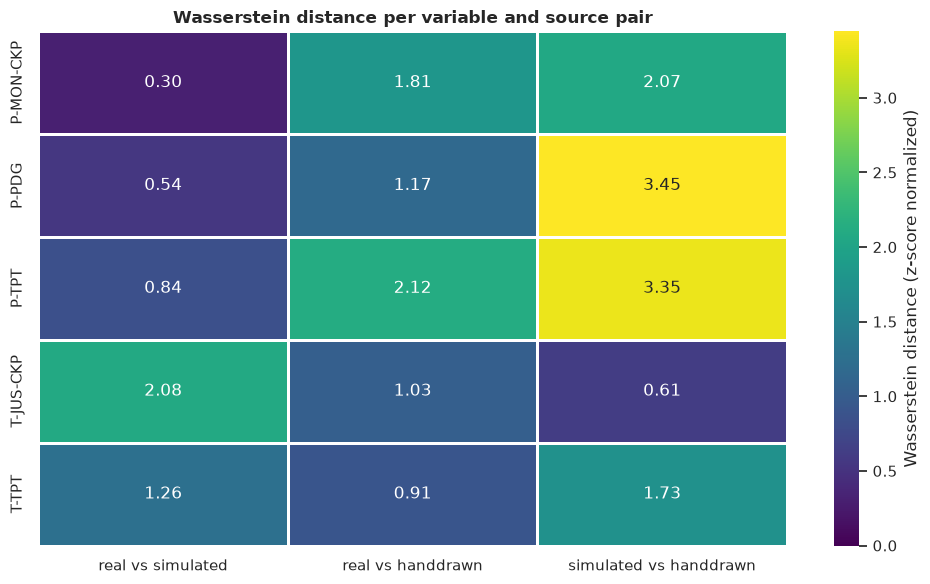

In [8]:
emd_pivot = emd_df.pivot(index='Variable', columns='source pair', values='Wasserstein_D')
emd_pivot = emd_pivot[[c for c in pair_order if c in emd_pivot.columns]]

fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(emd_pivot, annot=True, fmt='.2f', cmap='viridis',
            linewidths=1, vmin=0,
            cbar_kws={'label': 'Wasserstein distance (z-score normalized)'}, ax=ax)
ax.set_title('Wasserstein distance per variable and source pair',
             fontweight='bold')
ax.set_ylabel('')
ax.set_xlabel('')
plt.tight_layout()
plt.show()

Most distant variable: P-TPT
Least distant variable: T-JUS-CKP


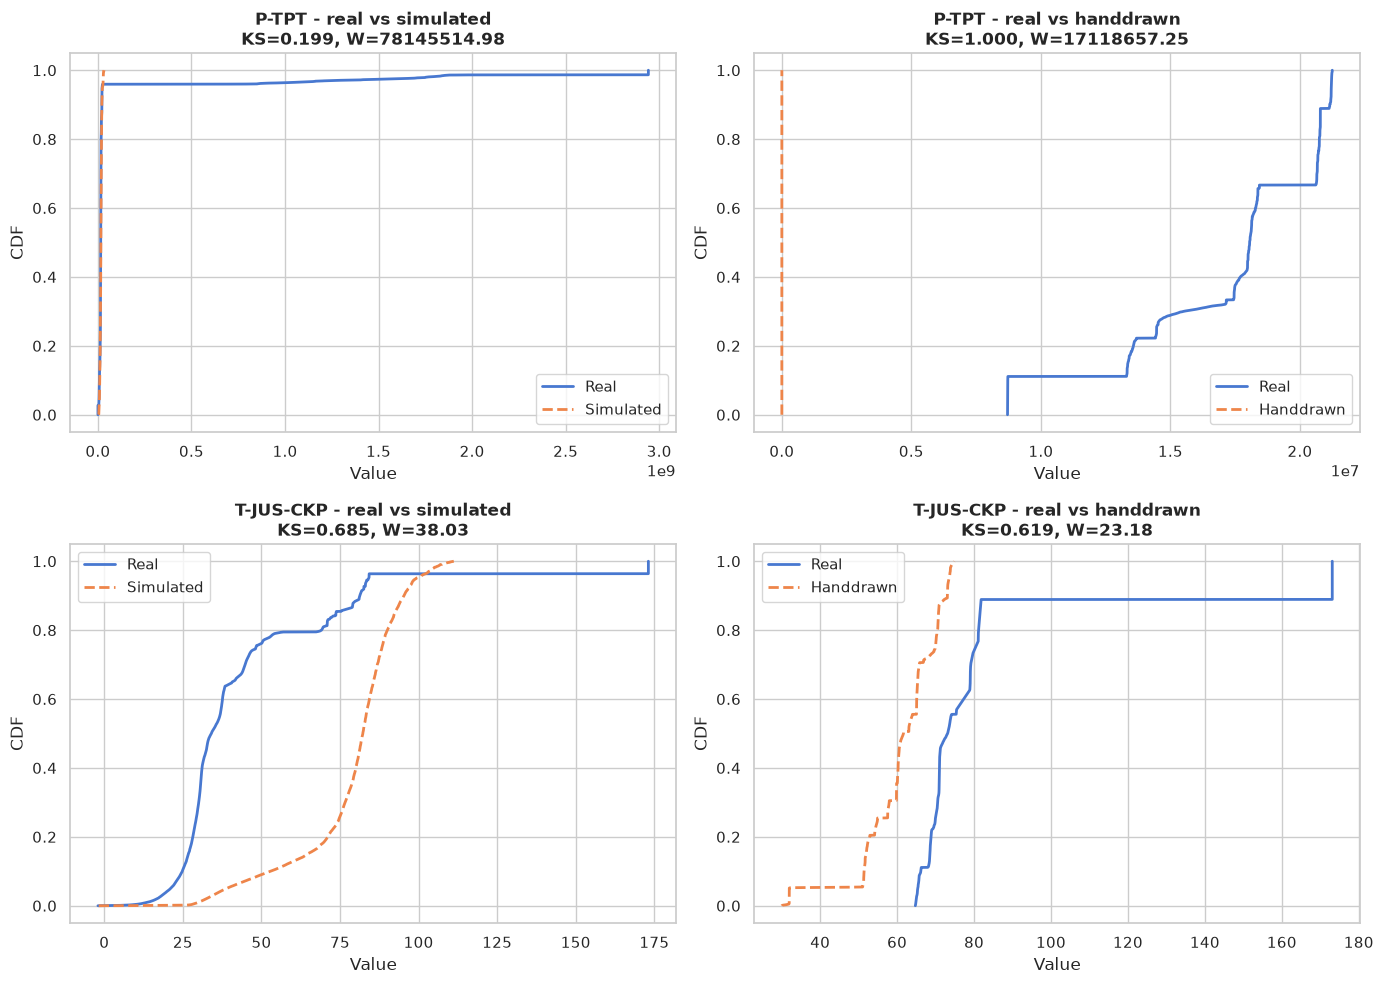

In [9]:
emd_pivot['mean_dist'] = emd_pivot.mean(axis=1)
most_distant_var = emd_pivot['mean_dist'].idxmax()
least_distant_var = emd_pivot['mean_dist'].idxmin()
print(f'Most distant variable: {most_distant_var}')
print(f'Least distant variable: {least_distant_var}')

source_pair_plots = [('real', 'simulated'), ('real', 'handdrawn')]
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for row_idx, var in enumerate([most_distant_var, least_distant_var]):
    for col_idx, (s1, s2) in enumerate(source_pair_plots):
        ax = axes[row_idx][col_idx]
        viable = get_viable_classes(data, s1, s2)
        if not viable:
            ax.text(0.5, 0.5, f'No common classes\nbetween {s1} and {s2}',
                    ha='center', va='center', transform=ax.transAxes, fontsize=10)
            ax.set_title(f'{var} - {s1} vs {s2}', fontweight='bold')
            continue

        vals1 = collect_observations(data, s1, var, viable, max_per_instance=5000)
        vals2 = collect_observations(data, s2, var, viable, max_per_instance=5000)

        for vals, src_label, ls in [(vals1, s1, '-'), (vals2, s2, '--')]:
            sorted_vals = np.sort(vals)
            cdf = np.linspace(0, 1, len(sorted_vals))
            ax.plot(sorted_vals, cdf, ls=ls, linewidth=2, label=src_label.capitalize())

        ks_d = ks_2samp(vals1, vals2).statistic
        w_d = wasserstein_distance(vals1, vals2)
        ax.set_title(f'{var} - {s1} vs {s2}\nKS={ks_d:.3f}, W={w_d:.2f}', fontweight='bold')
        ax.legend()
        ax.set_xlabel('Value')
        ax.set_ylabel('CDF')
        
plt.tight_layout()
plt.show()

The CDF overlay confirms what the numerical distances show: when the curves are well separated (e.g., P-TPT for real vs simulated), the distance is large; when they overlap (e.g., T-JUS-CKP), it is small. This validates that the metrics reflect real distribution differences and not artifacts.

Only the nearest and most distant source pairs are shown for clarity.

## 4. CORAL (Correlation Alignment)

CORAL measures the difference in correlation structure between two sources. We will compute it on z-score standardized data, both overall per source pair and per class for real vs simulated.

- **Metric**: Frobenius norm of the covariance difference, normalized by the squared number of variables
- **Range**: 0 (identical correlation structures), unbounded above
- **Data**: all observations pooled per source and class

In [10]:
def compute_coral(data: dict, source_a: str, source_b: str, classes=None) -> tuple:
    """
    Compute CORAL distance between two sources on standardized data.
    Returns the Frobenius norm of covariance difference, normalized by d^2.
    Data is z-score standardized per variable to ensure comparable scales.

    Args:
        data (dict): The dataset dictionary.
        source_a (str): The first source.
        source_b (str): The second source.
        classes (list, optional): List of class codes to include. If None, all viable classes are used.
    Returns:
        tuple: (coral_distance, common_columns) where coral_distance is the computed CORAL distance and common_columns is the list of variables used in the computation.
    """
    if classes is None:
        classes = get_viable_classes(data, source_a, source_b)
    
    frames_a, frames_b = [], []
    for cls in classes:
        for src, frames in [(source_a, frames_a), (source_b, frames_b)]:
            if src in data.get(cls, {}):
                for inst in data[cls][src]:
                    df = inst['data']
                    cols = [c for c in VARIABLE_NAMES if c in df.columns]
                    valid_cols = [c for c in cols if not df[c].isna().all()]
                    if valid_cols:
                        frames.append(df[valid_cols])
    
    if not frames_a or not frames_b:
        return None, None
    
    combined_a = pd.concat(frames_a, ignore_index=True)
    combined_b = pd.concat(frames_b, ignore_index=True)
    
    common_cols = list(set(combined_a.columns) & set(combined_b.columns))
    if len(common_cols) < 2:
        return None, None
    
    # Z-score normalize each source independently
    for col in common_cols:
        mean_a, std_a = combined_a[col].mean(), combined_a[col].std()
        mean_b, std_b = combined_b[col].mean(), combined_b[col].std()
        if std_a > 0:
            combined_a[col] = (combined_a[col] - mean_a) / std_a
        if std_b > 0:
            combined_b[col] = (combined_b[col] - mean_b) / std_b
    
    cov_a = combined_a[common_cols].cov().values
    cov_b = combined_b[common_cols].cov().values
    
    d = len(common_cols)
    coral = np.linalg.norm(cov_a - cov_b, ord='fro') / (d * d)
    return coral, common_cols

coral_results = []
for s1, s2 in source_pairs:
    coral_val, _ = compute_coral(data, s1, s2)
    if coral_val is not None:
        coral_results.append({'source pair': f'{s1} vs {s2}', 'CORAL': coral_val})

coral_per_class = []
for cls in sorted(data.keys()):
    coral_val, cols = compute_coral(data, 'real', 'simulated', classes=[cls])
    if coral_val is not None:
        coral_per_class.append({
            'Class': cls,
            'Event': CLASS_NAMES[cls][:25],
            'CORAL': coral_val,
            'Variables': len(cols),
        })

coral_df = pd.DataFrame(coral_results)
coral_cls_df = pd.DataFrame(coral_per_class)
print('Overall CORAL distances:')
display(coral_df)
print(f'\nPer-class CORAL (real vs simulated):')
display(coral_cls_df)


Overall CORAL distances:


,source pair,CORAL
0,real vs simulated,0.077498
1,real vs handdrawn,0.109339
2,simulated vs handdrawn,0.121754



Per-class CORAL (real vs simulated):


,Class,Event,CORAL,Variables
0,1,Abrupt Increase of BSW,0.143195,5
1,2,Spurious Closure of DHSV,0.094465,5
2,3,Severe Slugging,0.100480,5
3,5,Rapid Productivity Loss,0.128080,5
4,6,Quick Restriction in PCK,0.142449,4
5,8,Hydrate in Production Lin,0.188861,4


CORAL captures differences in correlation structure. Real vs hand-drawn and simulated vs hand-drawn show large values, confirming that the hand-drawn instances have fundamentally different correlation patterns (also visible in the EDA correlation heatmaps).

Per-class CORAL (real vs simulated) is only computed for classes present in both sources: classes 0, 4, and 7 are missing because they have no simulated instances. Class 4 (Flow Instability) has 344 real instances but zero simulated ones, so the correlation cannot be compared for that class. 

The values vary by event type: class 8 (Hydrate) has the largest correlation structure difference, class 2 (DHSV closure) the smallest.

## 5. MMD (Maximum Mean Discrepancy)

MMD embeds both samples in a reproducing kernel Hilbert space and measures the distance between their mean embeddings. We will compute a multi-kernel version per variable and source pair.

- **Metric**: average MMD^2 over 5 RBF bandwidths, median heuristic
- **Range**: 0 (identical distributions), unbounded above
- **Data**: subsampled to 5000 observations per source to avoid MemoryError

In [11]:
from sklearn.metrics.pairwise import rbf_kernel, euclidean_distances

def compute_mmd(X: np.ndarray, Y: np.ndarray, sigma=None) -> float:
    """
    Compute unbiased MMD^2 between two samples using RBF kernel.
    
    Args:
        X (np.ndarray): Sample from distribution P.
        Y (np.ndarray): Sample from distribution Q.
        sigma (float, optional): Bandwidth for RBF kernel. If None, median heuristic is used.
    Returns:
        float: The computed MMD^2 value. Returns None if either sample has fewer than 10 observations.
    """
    n, m = len(X), len(Y)
    if n < 10 or m < 10:
        return None
    X = X.reshape(-1, 1) if X.ndim == 1 else X
    Y = Y.reshape(-1, 1) if Y.ndim == 1 else Y
    if sigma is None:
        dists = euclidean_distances(X, Y).flatten()
        sigma = np.median(dists[dists > 0]) if np.any(dists > 0) else 1.0
        if sigma == 0 or np.isnan(sigma): sigma = 1.0
    gamma = 1.0 / (2.0 * sigma * sigma)
    K_xx = rbf_kernel(X, X, gamma=gamma)
    K_yy = rbf_kernel(Y, Y, gamma=gamma)
    K_xy = rbf_kernel(X, Y, gamma=gamma)
    mmd2 = (np.sum(K_xx) - np.trace(K_xx)) / (n * (n - 1))
    mmd2 += (np.sum(K_yy) - np.trace(K_yy)) / (m * (m - 1))
    mmd2 -= 2.0 * np.mean(K_xy)
    return max(0, mmd2)

def compute_mkmmd(X: np.ndarray, Y: np.ndarray, sigmas: list = [0.5, 1.0, 2.0, 4.0, 8.0]) -> float:
    """
    Multi-kernel MMD: average over multiple bandwidths.
    
    Args:
        X (np.ndarray): Sample from distribution P.
        Y (np.ndarray): Sample from distribution Q.
        sigmas (list): List of bandwidths for RBF kernels.
    Returns:
        float: The average MMD^2 value across the specified bandwidths. Returns None if no valid MMD values are computed.
    """
    mmds = []
    for sigma in sigmas:
        m = compute_mmd(X, Y, sigma=sigma)
        if m is not None: mmds.append(m)
    return np.mean(mmds) if mmds else None

mmd_results = []
for s1, s2 in source_pairs:
    viable = get_viable_classes(data, s1, s2)
    if not viable: continue
    for var in VARIABLE_NAMES:
        vals1 = collect_observations(data, s1, var, viable)
        vals2 = collect_observations(data, s2, var, viable)
        if len(vals1) < 100 or len(vals2) < 100: continue
        
        # NOTE: necessary to avoid MemoryError
        if len(vals1) > 5000: vals1 = np.random.choice(vals1, 5000, replace=False)
        if len(vals2) > 5000: vals2 = np.random.choice(vals2, 5000, replace=False)

        pooled = np.concatenate([vals1, vals2])
        pm, ps = np.mean(pooled), np.std(pooled)
        if ps > 0: vals1, vals2 = (vals1 - pm)/ps, (vals2 - pm)/ps
        mmd_val = compute_mkmmd(vals1, vals2)
        if mmd_val is not None:
            mmd_results.append({'source pair': f'{s1} vs {s2}', 'variable': var, 'MMD': mmd_val})

mmd_df = pd.DataFrame(mmd_results)

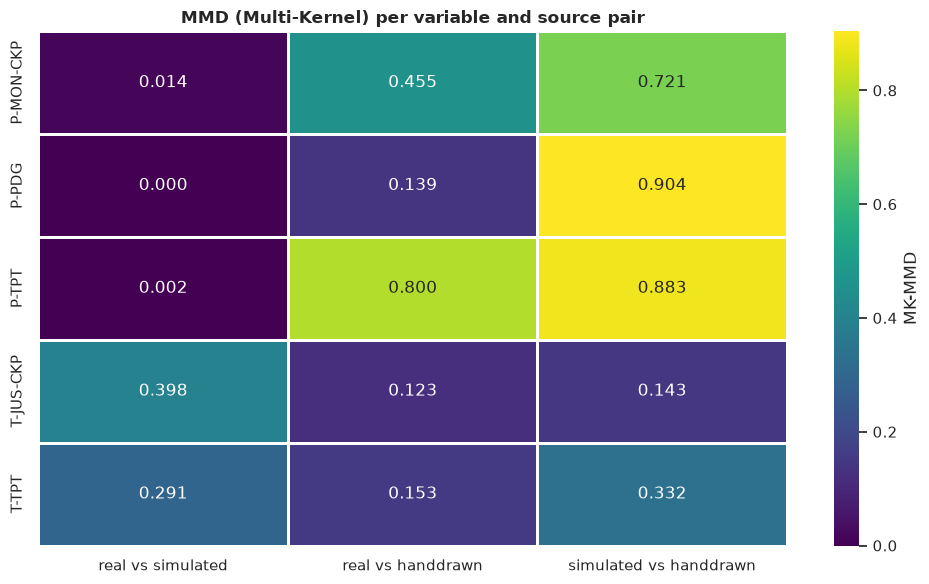

In [12]:
mmd_pivot = mmd_df.pivot(index='variable', columns='source pair', values='MMD')
mmd_pivot = mmd_pivot[[c for c in pair_order if c in mmd_pivot.columns]]

fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(mmd_pivot, annot=True, fmt='.3f', cmap='viridis', linewidths=1, vmin=0,
            cbar_kws={'label': 'MK-MMD'}, ax=ax)
ax.set_title('MMD (Multi-Kernel) per variable and source pair', fontweight='bold')
ax.set_ylabel('')
ax.set_xlabel('')
plt.tight_layout()
plt.show()


## 6. CMD (Central Moment Discrepancy)

CMD compares the central moments of the two distributions, going beyond mean and variance into skewness and kurtosis. We will compute it per variable and source pair.

- **Metric**: mean over moment orders 1-4 of the relative central moment difference
- **Range**: 0 (identical moments) to 1 (maximally different, normalized)
- **Interpretation**: high CMD means the distributions differ in shape, not just location and scale

In [13]:
def compute_cmd(X: np.ndarray, Y: np.ndarray, order=4) -> float:
    """
    Compute Central Moment Discrepancy up to the given order.
    
    Args:
        X (np.ndarray): Sample from distribution P.
        Y (np.ndarray): Sample from distribution Q.
        order (int): The order of moments to consider (default is 4).
    Returns:
        float: The computed CMD value. Returns None if either sample has fewer than 10 observations.
    """
    if len(X) < 10 or len(Y) < 10: return None
    def central_moment(data, m):
        if m == 1: return np.mean(data)
        return np.mean((data - np.mean(data))**m)
    total = 0.0
    for m in range(1, order + 1):
        c_x, c_y = central_moment(X, m), central_moment(Y, m)
        diff = abs(c_x - c_y)
        norm = abs(c_x) + abs(c_y)
        if norm > 0: total += diff / norm
    return total / order

cmd_results = []
for s1, s2 in source_pairs:
    viable = get_viable_classes(data, s1, s2)
    if not viable: continue
    for var in VARIABLE_NAMES:
        vals1 = collect_observations(data, s1, var, viable)
        vals2 = collect_observations(data, s2, var, viable)
        if len(vals1) < 100 or len(vals2) < 100: continue
        cmd_val = compute_cmd(vals1, vals2)
        if cmd_val is not None:
            cmd_results.append({'source pair': f'{s1} vs {s2}', 'Variable': var, 'CMD': cmd_val})

cmd_df = pd.DataFrame(cmd_results)

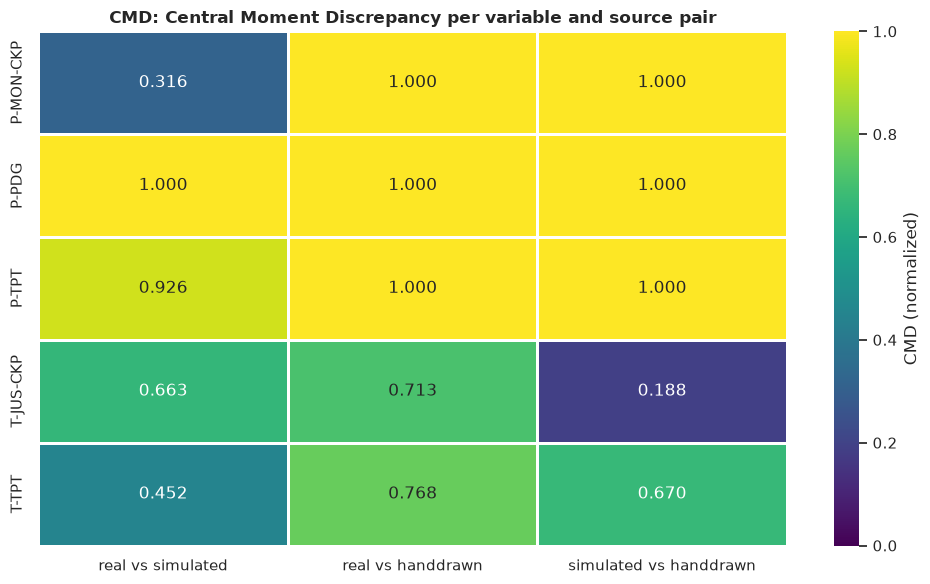

In [14]:
cmd_pivot = cmd_df.pivot(index='Variable', columns='source pair', values='CMD')
cmd_pivot = cmd_pivot[[c for c in pair_order if c in cmd_pivot.columns]]
fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(cmd_pivot, annot=True, fmt='.3f', cmap='viridis', linewidths=1, vmin=0, vmax=1,
            cbar_kws={'label': 'CMD (normalized)'}, ax=ax)
ax.set_title('CMD: Central Moment Discrepancy per variable and source pair',
             fontweight='bold')
ax.set_ylabel('')
ax.set_xlabel('')
plt.tight_layout()
plt.show()

CMD compares higher-order moments (skewness, kurtosis) beyond mean and variance. High CMD values indicate that the distributions differ in shape, not just in location and scale.

The results confirm that the sources have fundamentally different distribution shapes.

## 7. Proxy A-Distance (PAD)

PAD measures how well a classifier can separate the two sources. We will train an SGD classifier under cross-validation on pooled observations from each source pair, and derive the distance from its test error.

- **Metric**: `PAD = 2 * (1 - 2 * error)`, 5-fold CV error of a linear classifier
- **Range**: 0 (indistinguishable) to 1 (perfectly separable)
- **Interpretation**: PAD = 1.0 means the classifier separates the sources with zero error

In [15]:
def compute_pad(data: dict, source_a: str, source_b: str, classes: list, n_samples: int = 50000, cv_folds: int = 5) -> tuple:
    """Compute Proxy A-Distance between two sources.
    
    Args:
        data: Dictionary containing the dataset.
        source_a: Name of the first source.
        source_b: Name of the second source.
        classes: List of viable classes.
        n_samples: max observations to sample per source (for tractability)
        cv_folds: cross-validation folds
    Returns:
        pad: Proxy A-distance (0 = same, 1 = completely different)
        mean_error: mean CV test error
    """
    frames_a, frames_b = [], []
    for cls in classes:
        for src, frames in [(source_a, frames_a), (source_b, frames_b)]:
            if src in data.get(cls, {}):
                for inst in data[cls][src]:
                    df = inst['data']
                    cols = [c for c in VARIABLE_NAMES if c in df.columns]
                    valid = df[cols].dropna(how='all')
                    if len(valid) > 0:
                        frames.append(valid[cols].values)
    
    if not frames_a or not frames_b:
        return None, None
    
    X_a = np.vstack(frames_a)
    X_b = np.vstack(frames_b)
    
    if len(X_a) > n_samples:
        idx = np.random.choice(len(X_a), n_samples, replace=False)
        X_a = X_a[idx]
    if len(X_b) > n_samples:
        idx = np.random.choice(len(X_b), n_samples, replace=False)
        X_b = X_b[idx]
    
    def fill_nan(X: np.ndarray) -> np.ndarray:
        """
        Fill NaN values in the dataset with the median of each column. If a column is entirely NaN, fill with 0.0.

        Args:
            X (np.ndarray): Input data array with potential NaN values.
        Returns:
            np.ndarray: Data array with NaN values filled.
        """
        col_medians = np.nanmedian(X, axis=0)
        nan_mask = np.isnan(X)
        for j in range(X.shape[1]):
            if np.isnan(col_medians[j]):
                col_medians[j] = 0.0
            X[nan_mask[:, j], j] = col_medians[j]
        return X
    
    X_a = fill_nan(X_a)
    X_b = fill_nan(X_b)
    
    X = np.vstack([X_a, X_b])
    y = np.array([0]*len(X_a) + [1]*len(X_b))
    
    clf = Pipeline([
        ('scaler', StandardScaler()),
        ('sgd', SGDClassifier(loss='log_loss', max_iter=1000, tol=1e-3, random_state=42)),
    ])
    
    skf = StratifiedKFold(n_splits=cv_folds, shuffle=True, random_state=42)
    errors = []
    for train_idx, test_idx in skf.split(X, y):
        clf.fit(X[train_idx], y[train_idx])
        y_pred = clf.predict(X[test_idx])
        errors.append(1 - accuracy_score(y[test_idx], y_pred))
    
    mean_error = np.mean(errors)
    pad = max(0.0, min(1.0, 2 * (1 - 2 * mean_error))) # clipping between 0 and 1
    return pad, mean_error, len(X_a), len(X_b)

pad_results = []
for s1, s2 in source_pairs:
    viable = get_viable_classes(data, s1, s2)
    if len(viable) == 0:
        continue
    
    pad, err, n1, n2 = compute_pad(data, s1, s2, viable, n_samples=100_000)
    if pad is not None:
        pad_results.append({
            'source pair': f'{s1} vs {s2}',
            'PAD': pad,
            'CV_error': err,
            'n_samples': n1 + n2,
            'viable classes': len(viable),
        })

pad_df = pd.DataFrame(pad_results)
print('Proxy A-Distance results:')
display(pad_df)


Proxy A-Distance results:


,source pair,PAD,CV_error,n_samples,viable classes
0,real vs simulated,1.0,0.074745,200000,6
1,real vs handdrawn,1.0,0.000000,200000,2
2,simulated vs handdrawn,1.0,0.000000,200000,1


PAD measures classifier separability between sources. All three source pairs reach **PAD = 1.0**, meaning a classifier distinguishes them with zero error. If the sources are perfectly separable at the feature level, transfer learning must overcome a fundamental distribution mismatch, not just noise.

## 8. Distance summary

We will aggregate the six metrics over variables and compare the three source pairs side by side, for a unified view of the domain distances.

In [16]:
ks_agg = ks_df.groupby('source pair')['KS_statistic'].mean().reset_index()
ks_agg.columns = ['source pair', 'KS (mean)']

emd_agg = emd_df.groupby('source pair')['Wasserstein_D'].mean().reset_index()
emd_agg.columns = ['source pair', 'Wasserstein (mean)']
emd_agg['Wasserstein (mean)'] = emd_agg['Wasserstein (mean)'].round(1)

print('Aggregated metrics:')
display(ks_agg)
display(emd_agg)
display(coral_df)
display(pad_df[['source pair', 'PAD']])

Aggregated metrics:


,source pair,KS (mean)
0,real vs handdrawn,0.783451
1,real vs simulated,0.421234
2,simulated vs handdrawn,0.891059


,source pair,Wasserstein (mean)
0,real vs handdrawn,1.4
1,real vs simulated,1.0
2,simulated vs handdrawn,2.2


,source pair,CORAL
0,real vs simulated,0.077498
1,real vs handdrawn,0.109339
2,simulated vs handdrawn,0.121754


,source pair,PAD
0,real vs simulated,1.0
1,real vs handdrawn,1.0
2,simulated vs handdrawn,1.0


## 9. Intra-real splits: Well-to-well domain distance

We will measure the domain distance between real instances from different wells within the same event class, across all 6 metrics. Class 0 compares wells 1+2 vs 5+6, class 4 compares wells 1+2 vs 5+10.

In [17]:
def get_well_id(inst_id):
    if inst_id.startswith('WELL'): return inst_id.split('_')[0]
    return None

source_wells = ['WELL-00001', 'WELL-00002']
target_wells = ['WELL-00005', 'WELL-00006']

data_well = {}
for cls in sorted(data.keys()):
    data_well[cls] = {}
    src = [inst for inst in data[cls].get('real', []) if get_well_id(inst['id']) in source_wells]
    tgt = [inst for inst in data[cls].get('real', []) if get_well_id(inst['id']) in target_wells]
    if src: data_well[cls]['well_source'] = src
    if tgt: data_well[cls]['well_target'] = tgt

print('Well-based split instances per label:')
if 4 in data_well and 'well_source' in data_well[4] and 'well_target' in data_well[4]:
    print(f'\tClass 4 - well_source: {len(data_well[4]["well_source"])}')
    print(f'\tClass 4 - well_target: {len(data_well[4]["well_target"])}')
for k in ['well_source', 'well_target']:
    for c in sorted(data_well.keys()):
        if k in data_well[c]:
            print(f'\tClass {c} - {k}: {len(data_well[c][k])}')

Well-based split instances per label:
	Class 4 - well_source: 149
	Class 4 - well_target: 38
	Class 0 - well_source: 304
	Class 1 - well_source: 2
	Class 2 - well_source: 1
	Class 3 - well_source: 1
	Class 4 - well_source: 149
	Class 6 - well_source: 3
	Class 7 - well_source: 1
	Class 0 - well_target: 196
	Class 1 - well_target: 3
	Class 4 - well_target: 38
	Class 7 - well_target: 2


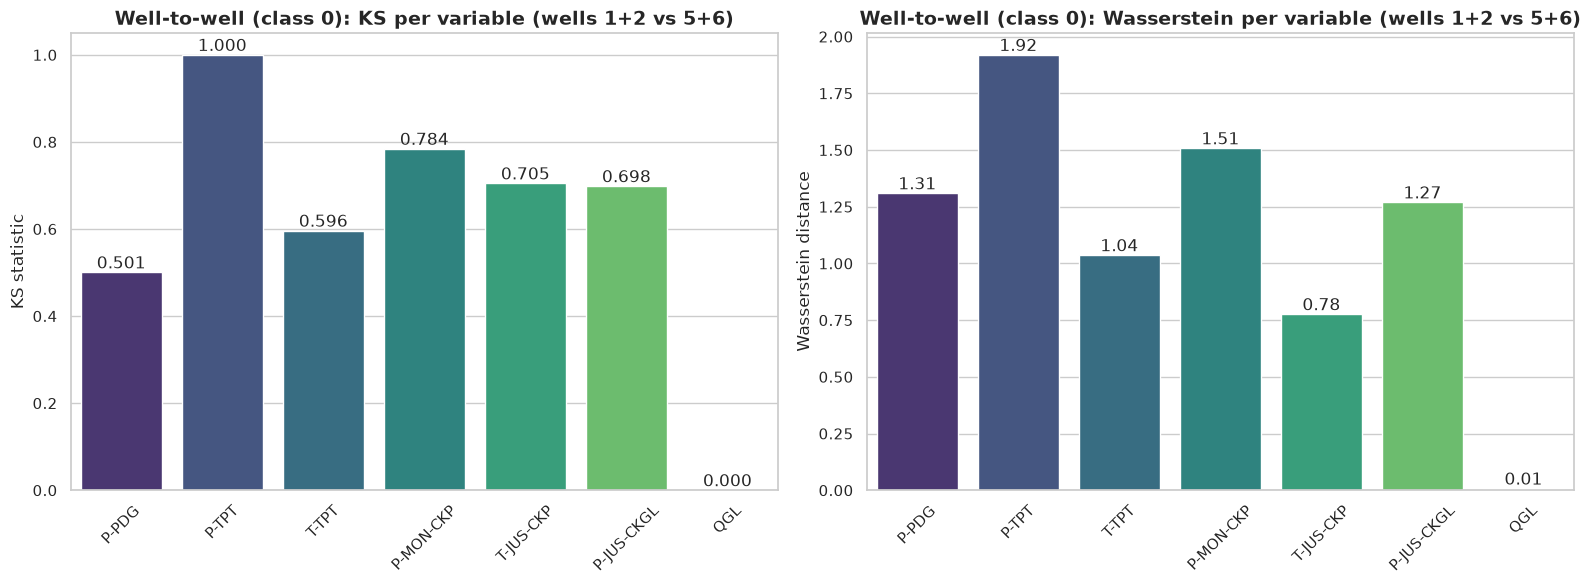

In [18]:
well_cls = [0]

def collect_well_obs(dw, wk, var, cls_list):
    vals = []
    for c in cls_list:
        if c in dw and wk in dw[c]:
            for inst in dw[c][wk]:
                if var in inst['data'].columns:
                    col = inst['data'][var].dropna().values[:20000]
                    if len(col) > 0: vals.extend(col)
    return np.array(vals)

# KS and Wasserstein per variable: wells 1+2 (source) vs 5+6 (target), class 0
ks_vals, w_vals, used_vars = [], [], []
for var in VARIABLE_NAMES:
    v1 = collect_well_obs(data_well, 'well_source', var, well_cls)
    v2 = collect_well_obs(data_well, 'well_target', var, well_cls)
    if len(v1) > 100 and len(v2) > 100:
        ks = ks_2samp(v1, v2).statistic
        pm, ps = np.mean(np.concatenate([v1, v2])), np.std(np.concatenate([v1, v2]))
        wd = wasserstein_distance((v1-pm)/ps, (v2-pm)/ps) if ps > 0 else 0
        ks_vals.append(ks)
        w_vals.append(wd)
        used_vars.append(var)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.barplot(x=used_vars, y=ks_vals, hue=used_vars, palette='viridis', legend=False, ax=axes[0])
axes[0].set_title('Well-to-well (class 0): KS per variable (wells 1+2 vs 5+6)',
                  fontsize=14, fontweight='bold')
axes[0].set_ylabel('KS statistic')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=45)
for i, v in enumerate(ks_vals):
    axes[0].text(i, v, f'{v:.3f}', ha='center', va='bottom')

sns.barplot(x=used_vars, y=w_vals, hue=used_vars, palette='viridis', legend=False, ax=axes[1])
axes[1].set_title('Well-to-well (class 0): Wasserstein per variable (wells 1+2 vs 5+6)',
                  fontsize=14, fontweight='bold')
axes[1].set_ylabel('Wasserstein distance')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=45)
for i, v in enumerate(w_vals):
    axes[1].text(i, v, f'{v:.2f}', ha='center', va='bottom')
plt.tight_layout()
plt.show()


Class 4 (Flow instability) well split:
	Source wells 1+2: 149 instances
	Target wells 5+10: 121 instances


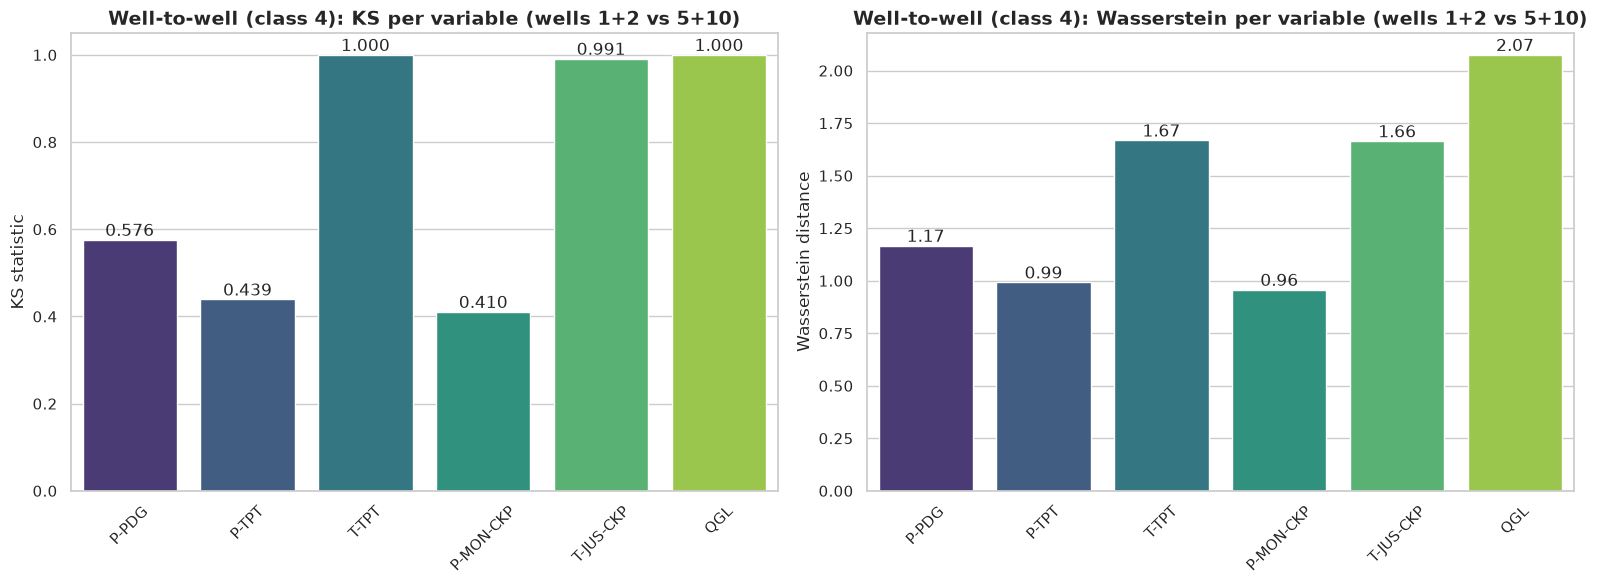

In [19]:
c4_src_wells = ['WELL-00001', 'WELL-00002']
c4_tgt_wells = ['WELL-00005', 'WELL-00010']

data_well_c4 = {}
for cls in [4]:
    data_well_c4[cls] = {}
    if cls in data and 'real' in data[cls]:
        data_well_c4[cls]['source'] = [inst for inst in data[cls]['real'] if get_well_id(inst['id']) in c4_src_wells]
        data_well_c4[cls]['target'] = [inst for inst in data[cls]['real'] if get_well_id(inst['id']) in c4_tgt_wells]

print('Class 4 (Flow instability) well split:')
print(f'\tSource wells 1+2: {len(data_well_c4[4]["source"])} instances')
print(f'\tTarget wells 5+10: {len(data_well_c4[4]["target"])} instances')

def collect_well_obs_c4(dw, wk, var):
    vals = []
    if 4 in dw and wk in dw[4]:
        for inst in dw[4][wk]:
            if var in inst['data'].columns:
                col = inst['data'][var].dropna().values[:20000]
                if len(col) > 0: vals.extend(col)
    return np.array(vals)

# KS and Wasserstein per variable: wells 1+2 (source) vs 5+10 (target), class 4
ks_vals_c4, w_vals_c4, used_vars_c4 = [], [], []
for var in VARIABLE_NAMES:
    v1 = collect_well_obs_c4(data_well_c4, 'source', var)
    v2 = collect_well_obs_c4(data_well_c4, 'target', var)
    if len(v1) > 100 and len(v2) > 100:
        ks = ks_2samp(v1, v2).statistic
        pm, ps = np.mean(np.concatenate([v1, v2])), np.std(np.concatenate([v1, v2]))
        wd = wasserstein_distance((v1-pm)/ps, (v2-pm)/ps) if ps > 0 else 0
        ks_vals_c4.append(ks)
        w_vals_c4.append(wd)
        used_vars_c4.append(var)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.barplot(x=used_vars_c4, y=ks_vals_c4, hue=used_vars_c4, palette='viridis', legend=False, ax=axes[0])
axes[0].set_title('Well-to-well (class 4): KS per variable (wells 1+2 vs 5+10)',
                  fontsize=14, fontweight='bold')
axes[0].set_ylabel('KS statistic')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=45)
for i, v in enumerate(ks_vals_c4):
    axes[0].text(i, v, f'{v:.3f}', ha='center', va='bottom')

sns.barplot(x=used_vars_c4, y=w_vals_c4, hue=used_vars_c4, palette='viridis', legend=False, ax=axes[1])
axes[1].set_title('Well-to-well (class 4): Wasserstein per variable (wells 1+2 vs 5+10)',
                  fontsize=14, fontweight='bold')
axes[1].set_ylabel('Wasserstein distance')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=45)
for i, v in enumerate(w_vals_c4):
    axes[1].text(i, v, f'{v:.2f}', ha='center', va='bottom')
plt.tight_layout()
plt.show()


  CORAL class 0: 0.0699
  CORAL class 4: 0.0566


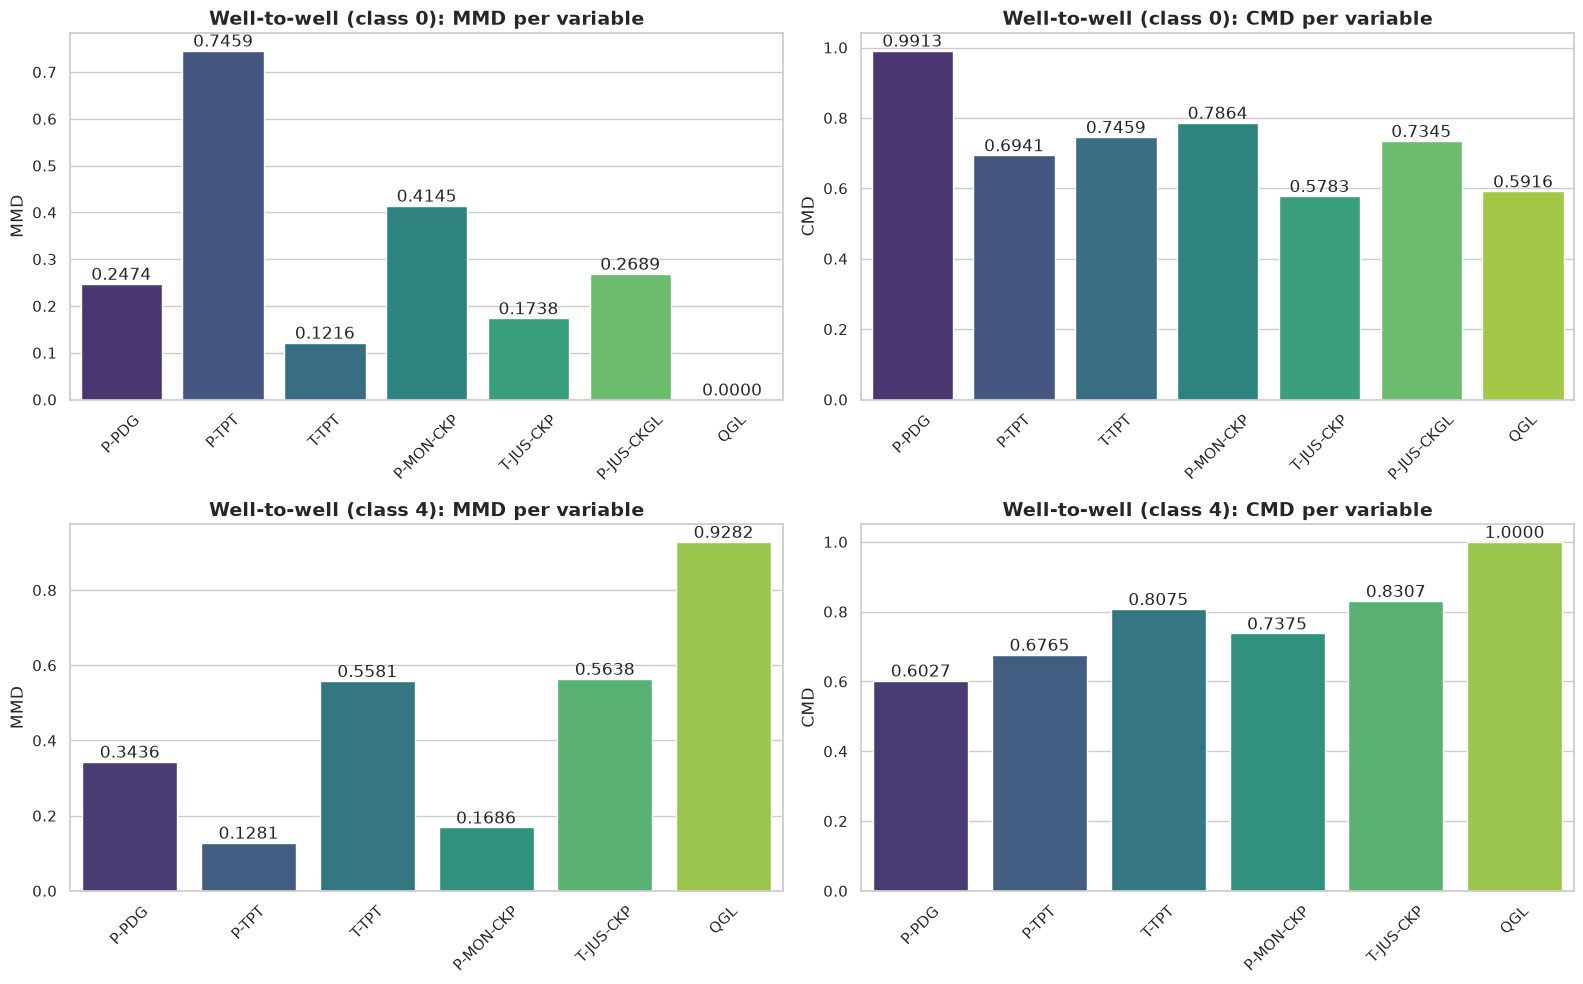

In [20]:
# CORAL distance: well-to-well (class 0 and class 4)
coral_c0, _ = compute_coral(data_well, 'well_source', 'well_target', classes=[0])
if coral_c0 is not None: print(f'  CORAL class 0: {coral_c0:.4f}')
coral_c4, _ = compute_coral(data_well_c4, 'source', 'target', classes=[4])
if coral_c4 is not None: print(f'  CORAL class 4: {coral_c4:.4f}')

def get_well_obs(dw: dict, wk: str, var: str, cls: int) -> np.ndarray:
    """
    Helper function to collect observations for a specific variable from a given well split and class.

    Args:
        dw (dict): The dataset dictionary containing well splits.
        wk (str): The well split key (e.g., 'well_source' or 'well_target').
        var (str): The variable name to extract observations for.
        cls (int): The class code to filter instances by.
    Returns:
        np.ndarray: Array of observations for the specified variable, well split, and class.
    """
    vals = []
    if cls in dw and wk in dw[cls]:
        for inst in dw[cls][wk]:
            if var in inst['data'].columns:
                col = inst['data'][var].dropna().values[:20000]
                if len(col) > 0: vals.extend(col)
    return np.array(vals)

# MMD distance: well-to-well (both classes)
mmd_rows = []
for wc, dw, wk_s, wk_t in [(0, data_well, 'well_source', 'well_target'), (4, data_well_c4, 'source', 'target')]:
    for var in VARIABLE_NAMES:
        v1 = get_well_obs(dw, wk_s, var, wc)
        v2 = get_well_obs(dw, wk_t, var, wc)
        if len(v1) > 100 and len(v2) > 100:
            # NOTE: necessary to avoid MemoryError
            if len(v1) > 5000: v1 = np.random.choice(v1, 5000, replace=False)
            if len(v2) > 5000: v2 = np.random.choice(v2, 5000, replace=False)
            pm, ps = np.mean(np.concatenate([v1, v2])), np.std(np.concatenate([v1, v2]))
            if ps > 0: v1, v2 = (v1-pm)/ps, (v2-pm)/ps
            mmd_val = compute_mkmmd(v1, v2)
            if mmd_val is not None:
                mmd_rows.append((wc, var, mmd_val))

# CMD distance: well-to-well (both classes)
cmd_rows = []
for wc, dw, wk_s, wk_t in [(0, data_well, 'well_source', 'well_target'), (4, data_well_c4, 'source', 'target')]:
    for var in VARIABLE_NAMES:
        v1 = get_well_obs(dw, wk_s, var, wc)
        v2 = get_well_obs(dw, wk_t, var, wc)
        if len(v1) > 100 and len(v2) > 100:
            cmd_val = compute_cmd(v1, v2)
            if cmd_val is not None:
                cmd_rows.append((wc, var, cmd_val))

# MMD (left) and CMD (right) per variable, one row per class
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
for row, wc in enumerate([0, 4]):
    for col, (rows, metric) in enumerate([(mmd_rows, 'MMD'), (cmd_rows, 'CMD')]):
        ax = axes[row, col]
        vars_ = [r[1] for r in rows if r[0] == wc]
        vals = [r[2] for r in rows if r[0] == wc]
        sns.barplot(x=vars_, y=vals, hue=vars_, palette='viridis', legend=False, ax=ax)
        ax.set_title(f'Well-to-well (class {wc}): {metric} per variable',
                     fontsize=14, fontweight='bold')
        ax.set_ylabel(metric)
        ax.set_xlabel('')
        ax.tick_params(axis='x', rotation=45)
        for i, v in enumerate(vals):
            ax.text(i, v, f'{v:.4f}', ha='center', va='bottom')
plt.tight_layout()
plt.show()


In [21]:
# Proxy A-Distance: well-to-well
pad0, err0, n1_0, n2_0 = compute_pad(data_well, 'well_source', 'well_target', classes=[0])
if pad0 is not None:
    print(f'\tClass 0: PAD={pad0:.3f} (CV error={err0:.3f}, n={n1_0}+{n2_0})')
    if pad0 > 0.5: print('\t\tDistinguishable wells for class 0')
    else: print('\t\tSimilar wells for class 0')

pad4, err4, n1_4, n2_4 = compute_pad(data_well_c4, 'source', 'target', classes=[4])
if pad4 is not None:
    print(f'\tClass 4: PAD={pad4:.3f} (CV error={err4:.3f}, n={n1_4}+{n2_4})')
    if pad4 > 0.5: print('\t\tDistinguishable wells for class 4')
    else: print('\t\tSimilar wells for class 4')

	Class 0: PAD=1.000 (CV error=0.000, n=50000+50000)
		Distinguishable wells for class 0
	Class 4: PAD=1.000 (CV error=0.000, n=50000+50000)
		Distinguishable wells for class 4


## 10. Intra-real splits: Time-period domain distance

We will measure the domain distance between real instances from different years on the same well, to detect concept drift. Class 0 compares well 2 in 2013 vs 2017, class 4 compares well 2 in 2013 vs 2014.

In [22]:
def get_year(inst_id: str) -> int | None:
    """
    Extract the year from an instance ID if it follows the expected format.

    Args:
        inst_id (str): The instance ID string.
    Returns:
        int | None: The extracted year as an integer, or None if the format is invalid.
    """
    parts = inst_id.split('_')
    if len(parts) >= 2 and parts[0].startswith('WELL'):
        ts = parts[-1]
        if len(ts) >= 8 and ts.isdigit(): return int(ts[:4])
    return None

CLS = 0
WID = 'WELL-00002'

inst_by_year = {}
if CLS in data and 'real' in data[CLS]:
    for inst in data[CLS]['real']:
        if get_well_id(inst['id']) == WID:
            y = get_year(inst['id'])
            if y: inst_by_year.setdefault(y, []).append(inst)

print(f'Class 0, {WID}: instances per year')
for y in sorted(inst_by_year):
    print(f'  {y}: {len(inst_by_year[y])}')

time_src = inst_by_year.get(2013, [])
time_tgt = inst_by_year.get(2017, [])
print(f'\nSource (2013): {len(time_src)}, Target (2017): {len(time_tgt)}')

if 4 in data and 'real' in data[4]:
    inst_by_year_4 = {}
    for inst in data[4]['real']:
        if get_well_id(inst['id']) == WID:
            y = get_year(inst['id'])
            if y: inst_by_year_4.setdefault(y, []).append(inst)
    print(f'Class 4, {WID}: instances per year')
    for y in sorted(inst_by_year_4):
        print(f'  {y}: {len(inst_by_year_4[y])}')
    time_src_4 = inst_by_year_4.get(2013, [])
    time_tgt_4 = inst_by_year_4.get(2014, [])
    print(f'\nClass 4 Source (2013): {len(time_src_4)}, Target (2014): {len(time_tgt_4)}')


Class 0, WELL-00002: instances per year
  2013: 8
  2017: 202

Source (2013): 8, Target (2017): 202
Class 4, WELL-00002: instances per year
  2013: 23
  2014: 90

Class 4 Source (2013): 23, Target (2014): 90


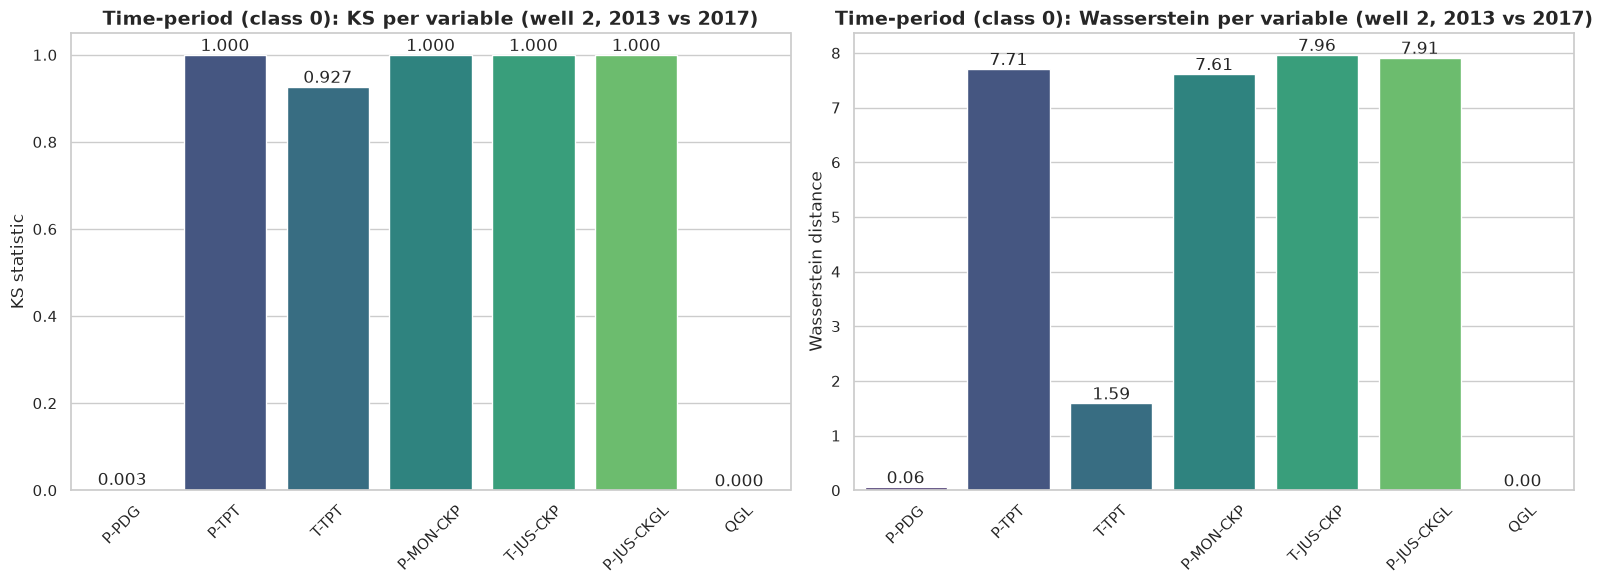

In [23]:
# KS and Wasserstein per variable: well 2, 2013 (source) vs 2017 (target), class 0
ks_vals_t0, w_vals_t0, used_vars_t0 = [], [], []
for var in VARIABLE_NAMES:
    vs, vt = [], []
    for inst in time_src:
        if var in inst['data'].columns: vs.extend(inst['data'][var].dropna().values[:20000])
    for inst in time_tgt:
        if var in inst['data'].columns: vt.extend(inst['data'][var].dropna().values[:20000])
    if len(vs) > 100 and len(vt) > 100:
        v1, v2 = np.array(vs), np.array(vt)
        ks = ks_2samp(v1, v2).statistic
        pm, ps = np.mean(np.concatenate([v1, v2])), np.std(np.concatenate([v1, v2]))
        wd = wasserstein_distance((v1-pm)/ps, (v2-pm)/ps) if ps > 0 else 0
        ks_vals_t0.append(ks)
        w_vals_t0.append(wd)
        used_vars_t0.append(var)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.barplot(x=used_vars_t0, y=ks_vals_t0, hue=used_vars_t0, palette='viridis', legend=False, ax=axes[0])
axes[0].set_title('Time-period (class 0): KS per variable (well 2, 2013 vs 2017)',
                  fontsize=14, fontweight='bold')
axes[0].set_ylabel('KS statistic')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=45)
for i, v in enumerate(ks_vals_t0):
    axes[0].text(i, v, f'{v:.3f}', ha='center', va='bottom')

sns.barplot(x=used_vars_t0, y=w_vals_t0, hue=used_vars_t0, palette='viridis', legend=False, ax=axes[1])
axes[1].set_title('Time-period (class 0): Wasserstein per variable (well 2, 2013 vs 2017)',
                  fontsize=14, fontweight='bold')
axes[1].set_ylabel('Wasserstein distance')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=45)
for i, v in enumerate(w_vals_t0):
    axes[1].text(i, v, f'{v:.2f}', ha='center', va='bottom')
plt.tight_layout()
plt.show()


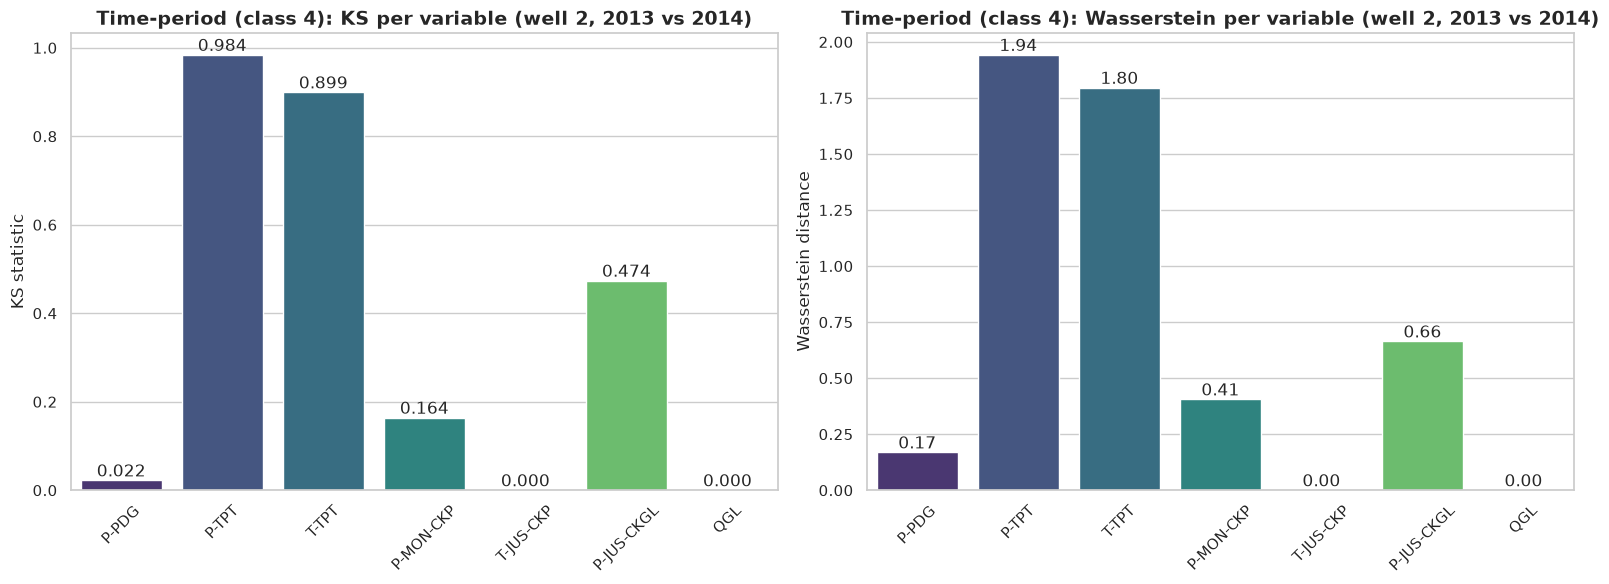

	Class 4 CORAL: 0.0293


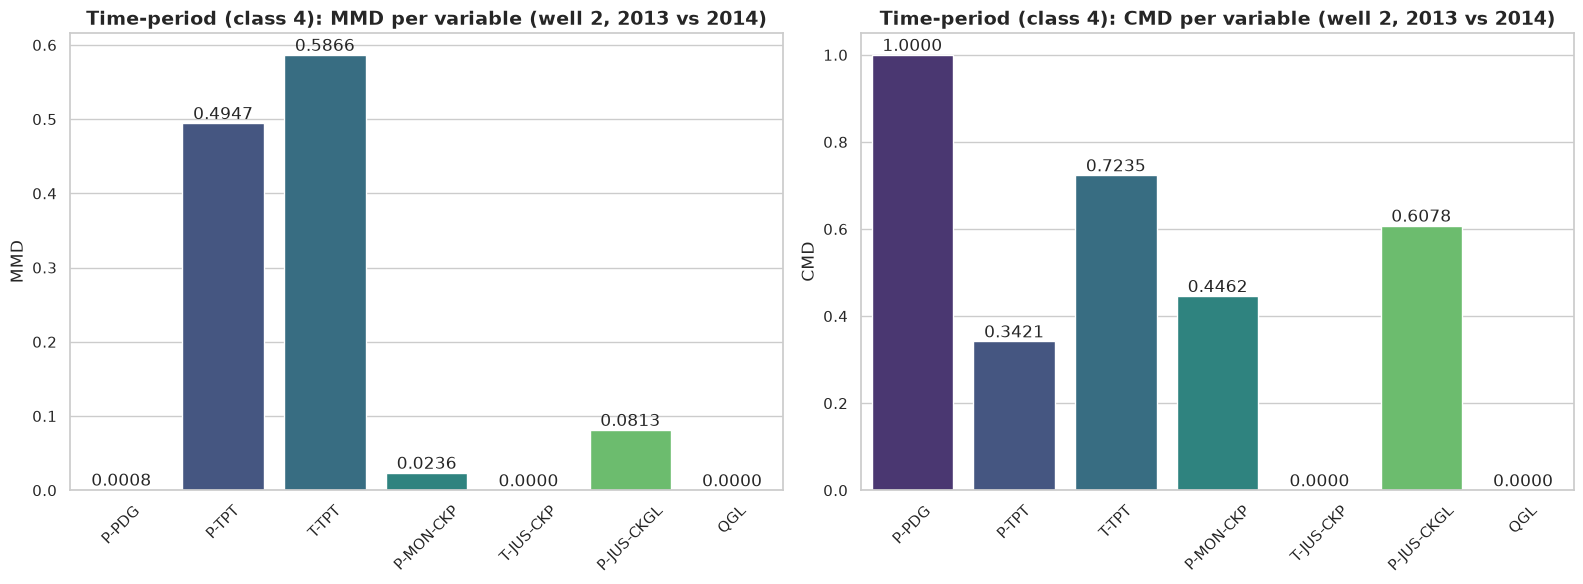

In [24]:
# KS and Wasserstein per variable: well 2, 2013 (source) vs 2014 (target), class 4
ks_vals_t4, w_vals_t4, used_vars_t4 = [], [], []
for var in VARIABLE_NAMES:
    vs, vt = [], []
    for inst in time_src_4:
        if var in inst['data'].columns: vs.extend(inst['data'][var].dropna().values[:20000])
    for inst in time_tgt_4:
        if var in inst['data'].columns: vt.extend(inst['data'][var].dropna().values[:20000])
    if len(vs) > 100 and len(vt) > 100:
        v1, v2 = np.array(vs), np.array(vt)
        ks = ks_2samp(v1, v2).statistic
        pm, ps = np.mean(np.concatenate([v1, v2])), np.std(np.concatenate([v1, v2]))
        wd = wasserstein_distance((v1-pm)/ps, (v2-pm)/ps) if ps > 0 else 0
        ks_vals_t4.append(ks)
        w_vals_t4.append(wd)
        used_vars_t4.append(var)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.barplot(x=used_vars_t4, y=ks_vals_t4, hue=used_vars_t4, palette='viridis', legend=False, ax=axes[0])
axes[0].set_title('Time-period (class 4): KS per variable (well 2, 2013 vs 2014)',
                  fontsize=14, fontweight='bold')
axes[0].set_ylabel('KS statistic')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=45)
for i, v in enumerate(ks_vals_t4):
    axes[0].text(i, v, f'{v:.3f}', ha='center', va='bottom')

sns.barplot(x=used_vars_t4, y=w_vals_t4, hue=used_vars_t4, palette='viridis', legend=False, ax=axes[1])
axes[1].set_title('Time-period (class 4): Wasserstein per variable (well 2, 2013 vs 2014)',
                  fontsize=14, fontweight='bold')
axes[1].set_ylabel('Wasserstein distance')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=45)
for i, v in enumerate(w_vals_t4):
    axes[1].text(i, v, f'{v:.2f}', ha='center', va='bottom')
plt.tight_layout()
plt.show()

# CORAL, MMD, CMD for time-period (class 4)
def build_time_data(data: dict, cls: int, well_id: str, year_src: int, year_tgt: int) -> dict:
    """
    Build a dictionary containing source and target instances for a specific class, well, and years.

    Args:
        data (dict): The dataset dictionary.
        cls (int): The class code to filter instances by.
        well_id (str): The well ID to filter instances by.
        year_src (int): The source year to filter instances by.
        year_tgt (int): The target year to filter instances by.
    Returns:
        dict: A dictionary with the structure {cls: {'src': [...], 'tgt': [...]}} containing the filtered instances.
    """
    td = {cls: {}}
    td[cls]['src'] = []
    td[cls]['tgt'] = []
    for inst in data.get(cls, {}).get('real', []):
        if get_well_id(inst['id']) == well_id:
            y = get_year(inst['id'])
            if y == year_src: td[cls]['src'].append(inst)
            if y == year_tgt: td[cls]['tgt'].append(inst)
    return td

td_4 = build_time_data(data, 4, 'WELL-00002', 2013, 2014)
coral_t4, _ = compute_coral(td_4, 'src', 'tgt', classes=[4])
if coral_t4 is not None: print(f'\tClass 4 CORAL: {coral_t4:.4f}')

# MMD per variable (class 4)
mmd_t4, cmd_t4, vars_t4 = [], [], []
for var in VARIABLE_NAMES:
    vs, vt = [], []
    for inst in td_4[4]['src']:
        if var in inst['data'].columns: vs.extend(inst['data'][var].dropna().values[:20000])
    for inst in td_4[4]['tgt']:
        if var in inst['data'].columns: vt.extend(inst['data'][var].dropna().values[:20000])
    if len(vs) > 100 and len(vt) > 100:
        v1, v2 = np.array(vs), np.array(vt)
        # NOTE: necessary to avoid MemoryError 
        if len(v1) > 5000: v1 = np.random.choice(v1, 5000, replace=False)
        if len(v2) > 5000: v2 = np.random.choice(v2, 5000, replace=False)
        pm, ps = np.mean(np.concatenate([v1, v2])), np.std(np.concatenate([v1, v2]))
        if ps > 0: v1, v2 = (v1-pm)/ps, (v2-pm)/ps
        mmd_val = compute_mkmmd(v1, v2)
        if mmd_val is not None:
            mmd_t4.append(mmd_val)
            vars_t4.append(var)

for var in VARIABLE_NAMES:
    vs, vt = [], []
    for inst in td_4[4]['src']:
        if var in inst['data'].columns: vs.extend(inst['data'][var].dropna().values[:20000])
    for inst in td_4[4]['tgt']:
        if var in inst['data'].columns: vt.extend(inst['data'][var].dropna().values[:20000])
    if len(vs) > 100 and len(vt) > 100:
        v1, v2 = np.array(vs), np.array(vt)
        cmd_val = compute_cmd(v1, v2)
        if cmd_val is not None:
            cmd_t4.append(cmd_val)

# MMD (left) and CMD (right) per variable (class 4)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.barplot(x=vars_t4, y=mmd_t4, hue=vars_t4, palette='viridis', legend=False, ax=axes[0])
axes[0].set_title('Time-period (class 4): MMD per variable (well 2, 2013 vs 2014)',
                  fontsize=14, fontweight='bold')
axes[0].set_ylabel('MMD')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=45)
for i, v in enumerate(mmd_t4):
    axes[0].text(i, v, f'{v:.4f}', ha='center', va='bottom')

sns.barplot(x=vars_t4, y=cmd_t4, hue=vars_t4, palette='viridis', legend=False, ax=axes[1])
axes[1].set_title('Time-period (class 4): CMD per variable (well 2, 2013 vs 2014)',
                  fontsize=14, fontweight='bold')
axes[1].set_ylabel('CMD')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=45)
for i, v in enumerate(cmd_t4):
    axes[1].text(i, v, f'{v:.4f}', ha='center', va='bottom')
plt.tight_layout()
plt.show()


## 11. Summary

| Finding | Value |
|---|---|
| **All pairs are perfectly separable** | PAD = 1.0 for every source pair and intra-real split |
| **Closest marginals, worst transfer** | real vs simulated has the lowest KS, Wasserstein, and CORAL, yet stage 2 reports the Simulated to Real F1 dropping from 0.98 to 0.07 |
| **Hand-drawn is the most distinct source** | highest KS and CORAL against real, while Hand-drawn to Real transfers moderately (0.90 to 0.65) |
| **Higher-order moments matter** | CMD attributes much of the gap to skewness and kurtosis, not only mean and variance |
| **Wells drift within a fault** | class 4 wells 1+2 vs 5+10 are perfectly separable (PAD = 1.0), CORAL 0.057 |
| **Time drift is measurable** | class 0 well 2, 2013 vs 2017: PAD = 1.0, some variables at KS = 1.0 |
| **Distance does not predict transferability** | the statistically closest pair (real vs simulated) coincides with the worst transfer, so the effect depends on the generator, not the distance |
